<h1 align=center><font size = 5> 탐색적데이터분석(EDA)</font></h1>

이 섹션에서는 특징 혹은 피처를 사용하여 자동차 가격을 예측할 수 있는지 확인하는 몇 가지 방법을 살펴 봅니다.

## 목차

1. 데이터 가져오기(Import)<
2. 시각화를 통해 개별 피처의 패턴 분석
3. 기술 통계 분석
4. 그룹핑(Grouping) 기본
5. 상관관계 및 인과관계
6. 분산분석(ANOVA)

<h2>자동차 가격에 가장 큰 영향을 미치는 주요 특징은 무엇일까요?</h2>

<h2 id="import_data">1. 데이터 가져오기(Import)</h2>

 필요한 라이브러리 불러오기(Import)

In [1]:
import pandas as pd
import numpy as np

데이터를 로드하고 데이터 프레임 df에 저장:

다음 데이터 세트는 IBM의 Cloud object storage 서비스 상에 호스팅되어 있습니다. 무료 스토리지 공간을 활용하고자 하시면
<a href="https://cocl.us/DA101EN_object_storage"> 여기</a>를 클릭하십시오.

In [2]:
# path='https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DA0101EN/automobileEDA.csv'
path = 'automobileEDA.csv'
df = pd.read_csv(path)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<h2 id="pattern_visualization">2. 시각화를 통해 개별 피처의 패턴 분석</h2>

seaborn을 설치를 위해 python 패키지 관리자 인 pip를 사용합니다.

In [3]:
# %%capture
# ! pip install seaborn

시각화 패키지 "Matplotlib"및 "Seaborn"을 가져옵니다. Jupyterlab에서 플롯하려면 "%matplotlib widget"을 잊지 마십시오.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# %matplotlib widget
# %matplotlib inline 

In [5]:
plt.style.use('seaborn')

<h3>2.1 올바른 시각화 방법의 선택</h3>
<p>개별 변수를 시각화할 때 먼저 다루고있는 변수 타입을 이해하는 것이 중요합니다. 그러면 해당 변수에 적합한 시각화 방법을 찾는 데 도움이됩니다. </p>

In [6]:
# list the data types for each column
print(df.dtypes)

symboling              int64
normalized-losses      int64
make                  object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
horsepower-binned     object
diesel                 int64
gas                    int64
dtype: object


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h5> 문제  #1:</h5>

<b>"peak-rpm"열의 데이터 타입은 무엇입니까?</b>
</div>

In [7]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

float64

-->

예를 들어 "corr"메소드를 사용하여 "int64"또는 "float64"타입의 변수 간 상관관계(correlation)를 계산할 수 있습니다.

In [8]:
df.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


<AxesSubplot:>

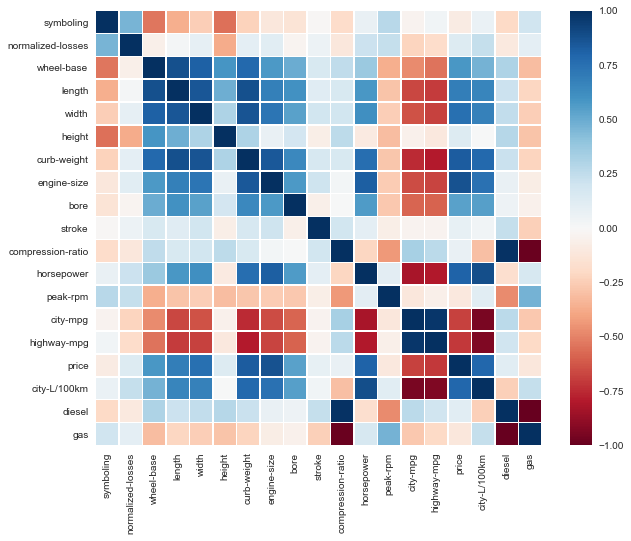

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(data = df.corr(),linewidths=.5, cmap='RdBu')

대각선 요소는 상관관계가 항상 1입니다. 이 노트북에서는 상관관계 중 Pearson 상관관계에 대해 연구 할 것입니다.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h5> 문제  #2: </h5>

<p> bore, stroke,compression-ratio , horsepower간의 상관 관계를 확인하십시오. </p>
<p> 힌트: 해당 열 선택시 다음 구문을 사용하십시오. df[['bore','stroke' ,'compression-ratio','horsepower']] </p>
</div>

In [10]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

df[['bore', 'stroke', 'compression-ratio', 'horsepower']].corr()  

-->

<h3>2.2 연속형 수치 변수(Continuous numerical variables):</h3> 

<p> 연속형 수치 변수는 특정 범위 내 값을 저장하는 변수입니다. 연속형 수치 변수는 "int64" 또는 "float64" 타입을 가질 수 있습니다. 이러한 변수를 시각화하는 가장 좋은 방법은 데이터에 적합한 회귀선을 가진 산점도(scatter plot)을 이용하는 것입니다</p>

<p> 개별 변수와 price간 (선형)관계 이해을 위해, 데이터에 대한 산점도와 회귀선을 표시하는 "regplot"을 사용하여 수행 할 수 있습니다. </p>

선형 관계의 몇 가지 예를 살펴 보겠습니다.

<h4>2.2.1 양의 선형 관계(Positive linear relationship)</h4>

"engine-size"와 "price"의 산점도(scatter plot)

Text(0, 0.5, 'Price')

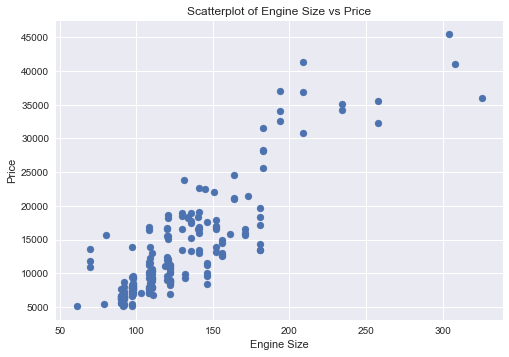

In [11]:
import matplotlib.pyplot as plt

x = df["engine-size"]
y = df["price"]

plt.scatter(x,y)
plt.title("Scatterplot of Engine Size vs Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")

(0.0, 53439.31768308523)

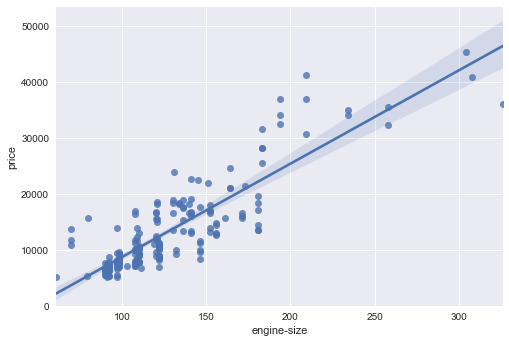

In [12]:
# 가격(price)에 대한 예측변수로서의 엔진크기(Engine size) 확인
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)

<p> engine-size가 올라감에 따라 price도 올라갑니다. 이것은 두 변수 간 직접적인 양의 상관 관계를 보여줍니다. 회귀선은 거의 완벽한 대각선을 이루고 있기 때문에 engine-size는 price에 대한 꽤 좋은 예측 변수(predictor)로 보입니다. </p>

'engine-size'와 'price'의 상관 관계를 살펴보면 약 0.87이라는 것을 알 수 있습니다.

In [13]:
df[["engine-size", "price"]].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


Highway-mpg는 price에 대한 잠재적 예측 변수(predictor variable)입니다.

<AxesSubplot:xlabel='highway-mpg', ylabel='price'>

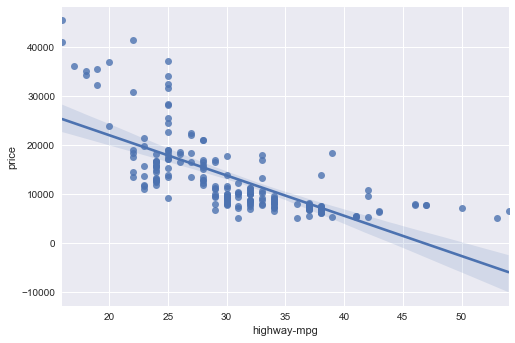

In [14]:
sns.regplot(x="highway-mpg", y="price", data=df)

<p>highway-mpg가 올라가면 price가 내려갑니다. 이것은 두 변수 간 반대의 즉, 음의 상관관계를 보여줍니다. highway-mpg는 잠재적으로 price를 예측할 수 있습니다. </p>

'highway-mpg'와 'price'간 상관 관계를 살펴보면 약 -0.704임을 알 수 있습니다.

In [15]:
df[['highway-mpg', 'price']].corr()

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


<h4>약한 선형 상관관계</h4>

"price"의 예측 변수로서의 "Peak-rpm"에 대해 살펴 보겠습니다.

<AxesSubplot:xlabel='peak-rpm', ylabel='price'>

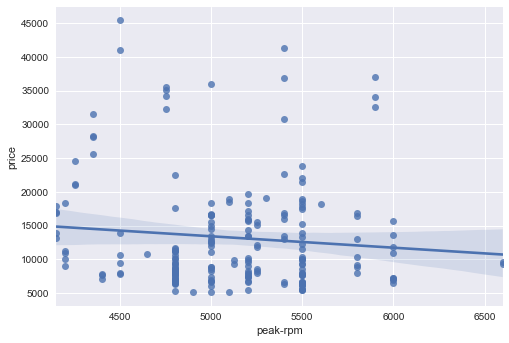

In [16]:
sns.regplot(x="peak-rpm", y="price", data=df)

<p>peak-rpm은 회귀선이 수평에 가깝기 때문에 price에 대한 좋은 예측자로 보이지 않습니다. 또한 데이터 포인트가 매우 산만하게 흩어져 있고 적합선에서 멀리 떨어져 있어 많은 변동성을 보여줍니다. 따라서 신뢰할 수있는 변수가 아닙니다. </p>

'peak-rpm'과 'price'사이의 상관 관계를 조사해보면 약 -0.101616입니다.

In [17]:
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h5> 문제  3 a): </h5>

<p> x = "stroke", y = "price"간 상관 관계를 구하십시오. </p>
<p> 힌트: 해당 열을 선택하려면 다음 구문을 사용하십시오. df[["stroke","price"]] </ p>
</div>

In [18]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

#The correlation is 0.0823, the non-diagonal elements of the table.
#code:
df[["stroke","price"]].corr() 

-->

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h5>문제  3 b):</h5>

<p> "price"와 "stroke"간 상관관계 결과로 선형 관계를 기대하는지요? </ p>
<p> "regplot()"함수를 사용하여 결과를 확인해봅시다</p>
</div>

In [19]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

#There is a weak correlation between the variable 'stroke' and 'price.' as such regression will not work well.  We #can see this use "regplot" to demonstrate this.

#Code: 
sns.regplot(x="stroke", y="price", data=df)

-->

<h3>2.3 범주형 변수(Categorical variables)</h3>

<p> 범주형 변수는 유한한 수의 고유 그룹 혹은 카테고리(범주)를 특징(characteristics)으로 가집니다. 범주형 변수의 타입은 "object" 또는 "int64"일 수 있습니다. 범주형 변수를 시각화하는 좋은 방법은 boxplot(상자 그림)을 사용하는 것입니다. </p>

"body-style"과 "price"간 관계를 살펴 보겠습니다.

<AxesSubplot:xlabel='body-style', ylabel='price'>

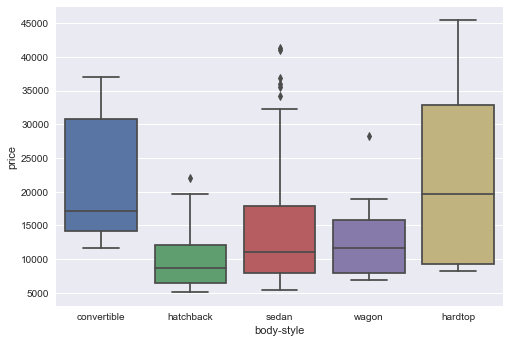

In [20]:
sns.boxplot(x="body-style", y="price", data=df)

<p> 서로 다른 body-style 카테고리 간의 price 분포가 상당히 많이 겹치기 때문에 body-style로 price를 제대로 예측할 수 없습니다. 이제 "engine-location"과 "price"를 살펴 보겠습니다. </p>

<AxesSubplot:xlabel='engine-location', ylabel='price'>

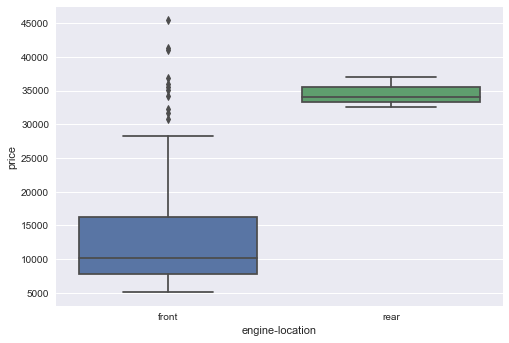

In [21]:
sns.boxplot(x="engine-location", y="price", data=df)

<p>위 그림에서 front, rear 두개의 engine-location 카테고리 사이의 price 분포를 보면, engine-location이 price의 좋은 예측변수로 삼을 만큼 충분히 price 분포가 구별되는 것을 확인할 수 있습니다. </p>

"drive-wheels"와 "price"를 살펴 보겠습니다.

<AxesSubplot:xlabel='drive-wheels', ylabel='price'>

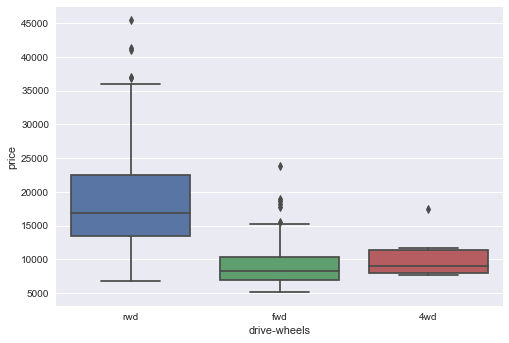

In [22]:
# drive-wheels
sns.boxplot(x="drive-wheels", y="price", data=df)

<p>위에서 서로 다른 drive-sheels 카테고리 간의 price 분포가 다르다는 것을 알 수 있습니다. 그러므로 drive-wheels은 잠재적으로 price에 대한 예측 변수가 될 수 있습니다. </p>

<h2 id="discriptive_statistics">3. 기술 통계 분석</h2>

<p> 기술 분석 방법을 활용하여 변수들을 살펴 보겠습니다. </p>

<p> <b>describe</b> 함수는 모든 연속형 변수에 대해 기본적인 통계를 자동으로 계산합니다. 모든 NaN 값은 자동으로 통계에서 skip됩니다. </p>

기술 통계 분석시 다음이 표시됩니다.
<ul>
    <li> 해당 변수의 개수</li>
    <li> 평균</li>
    <li> 표준 편차(std) </li>
    <li> 최소값</li>
    <li> IQR(사 분위간 범위: 25 %, 50 %, 75 %)</li>
    <li> 최대값</li>
<ul>

다음과 같이 "describe" 메소드를 적용할 수 있습니다.

In [23]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


기본 설정(default)으로 "describe"는  object 타입 변수는 skip합니다. 'object' 타입 변수를 포함하고자 할 경우, 다음과 같은 옵션을 추가하여 "describe" 메소드를 적용 할 수 있습니다.

In [25]:
df.describe(include=['object'])

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


<h3>3.1 Value Counts</h3>

Value-counts는 해당 변수가 얼마나 많은 특징 단위를 가지고 있는지 확인하는 좋은 방법입니다. 다음과 같이 'drive-wheels'열에 "value_counts"메서드를 적용 할 수 있습니다. **'value_counts' 메소드는 Pandas Dataframe이 아닌 Pandas Series에서만 작동한다**는 사실을 잊지 마세요. 결과적으로 두 개의 대괄호 "df[['drive-wheels']]"가 아니라 "df['drive-wheels']"로 대괄호 하나만 포함됩니다.

In [26]:
df['drive-wheels'].value_counts()

fwd    118
rwd     75
4wd      8
Name: drive-wheels, dtype: int64

다음과 같이 series를 dataframe으로 변환 할 수 있습니다.

In [27]:
df['drive-wheels'].value_counts().to_frame()

,drive-wheels
fwd,118
rwd,75
4wd,8


위의 단계를 반복하되, 결과를 "drive_wheels_counts" 데이터 프레임에 저장하고 'drive-wheels'열의 이름을 'value_counts'로 바꿉니다.

In [28]:
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.rename(columns={'drive-wheels': 'value_counts'}, inplace=True)
drive_wheels_counts

,value_counts
fwd,118
rwd,75
4wd,8


이제 index의 이름을 'drive-wheels'로 변경하겠습니다.

In [29]:
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts

,value_counts
drive-wheels,
fwd,118
rwd,75
4wd,8


'engine-location'변수에 대해 위의 과정을 반복합니다. 

In [30]:
# engine-location as variable
engine_loc_counts = df['engine-location'].value_counts().to_frame()
engine_loc_counts.rename(columns={'engine-location': 'value_counts'}, inplace=True)
engine_loc_counts.index.name = 'engine-location'
engine_loc_counts.head(10)

,value_counts
engine-location,
front,198
rear,3


engine-location의 valeu counts를 확인해보면, price에 대한 좋은 예측 변수가 아닌 것을 확인할 수 있습니다. 이것은 rear 즉 후방 엔진이 장착된 자동차는 단지 3대이고, 이에 비해 front 엔진이 장착된 것은 198대가 있기 때문입니다. **이러한 변수를 사용시는 결과가 왜곡(skew)될 수 있습니다**. 따라서 engine-location에 대해서는 결론을 내릴 수 없습니다.

<h2 id="basic_grouping">4. 그룹핑(Grouping) 기본</h2>

"groupby"는 범주별로 데이터를 그룹화합니다. **데이터는 하나 또는 여러 변수를 기준으로 그룹화되며 개별 그룹에 대한 분석이 수행됩니다**.

예를 들어 "drive-wheels"변수로 그룹화 해보겠습니다. 세 가지 카테고리의 drive-sheels이 있음을 알 수 있습니다.

In [31]:
df['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

<p>평균적으로 어떤 타입의 drive wheel이 가장 가치(중고차 가격이 높은지)가 있는지 알고 싶다면 "drive-wheels"을 그룹화한 다음 평균을 낼 수 있습니다. </p>

<p>다음과 같이 'drive-wheels', 'body-style', 'price'열을 선택 후, "df_group_one" 변수에 할당합니다. </p>

In [32]:
df_group_one = df[['drive-wheels','body-style','price']]

그런 다음 서로 다른 데이터 범주 각각에 대해 평균 price를 계산할 수 있습니다.

In [33]:
# grouping results
df_group_one = df_group_one.groupby(['drive-wheels'],as_index=False).mean()
# df_group_one = df_group_one.groupby(['drive-wheels']).mean()
df_group_one

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


<p> 위의 결과에 따르면 평균적으로 후륜구동(rear-wheel) 차량이 가장 비싸고 4륜(4-wheel)과 전륜(front-wheel)은 가격이 거의 같습니다. </p>

<p> 다음과 같이 여러 변수들로 그룹화할 수도 있습니다. 예를 들어 'drive-wheels'와 'body-style'을 기준으로 그룹화 해보겠습니다. 'drive-wheels'와 'body-style'의 고유 조합으로 데이터 프레임이 그룹화됩니다. 결과를 'grouped_test1'변수에 저장합니다. </p>

In [34]:
# grouping results
df_gptest = df[['drive-wheels','body-style','price']]
grouped_test1 = df_gptest.groupby(['drive-wheels','body-style'],as_index=False).mean()
# grouped_test1 = df_gptest.groupby(['drive-wheels','body-style']).mean()
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


<p>위의 그룹화된 데이터는 피벗 테이블로 변환시 시각화하기가 훨씬 쉽습니다. 피벗 테이블은 열에 하나의 변수가 있고 행에 다른 변수가 있는 Excel 스프레드시트 비슷한 스타일입니다.  "pivot" 메소드를 사용하여 데이터프레임을 피벗 테이블로 변환합니다. </p>

<p>이 때, drive-wheels을 테이블의 행으로 두고 body-style을 피벗하여 테이블의 열이 되도록 합니다. </p>

In [35]:
grouped_pivot = grouped_test1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

<p> 종종 일부 피벗 셀에 대한 데이터가 없을 수도 있습니다. 누락된 셀의 값을 0으로 채울 수 있지만 다른 값도 사용할 수 있습니다. 누락 데이터 처리는 매우 복잡한 주제로 관련된 별도 과정을 참조하시기 바랍니다.</p>

In [36]:
grouped_pivot = grouped_pivot.fillna(0) #fill missing values with 0
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h5>문제 4:</h5>

<p>"groupby" 함수를 사용하여 "body-style"을 기준으로 한 자동차의 평균 "price"을 찾으십시오.</p>
</div>

In [37]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

# grouping results
df_gptest2 = df[['body-style','price']]
grouped_test_bodystyle = df_gptest2.groupby(['body-style'],as_index= False).mean()
grouped_test_bodystyle

-->

"pyplot"을 import하지 않았다면 여기서 import하시기 바랍니다. 

<h4>변수: Drive Wheels, Body Style vs Price</h4>

히트맵을 사용하여 Body Style과 Price 간의 관계를 시각화 해 보겠습니다.

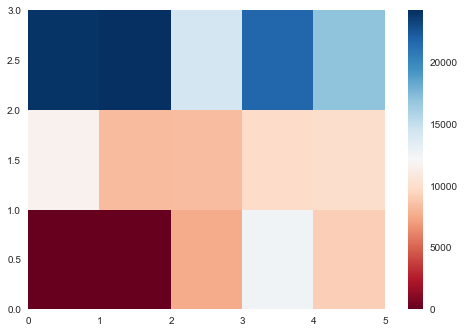

In [38]:
#use the grouped results
plt.pcolor(grouped_pivot, cmap='RdBu')
plt.colorbar()
plt.show()

<p> 히트맵은 세로축 'drive-wheel'과 가로축 'body-style'변수에 대해 색상에 비례하는 목표 변수(price)를 표시합니다. 이를 통해 price가 'drive-wheel' 및 'body-style'과 어떻게 관련되어 있는지 시각화 할 수 있습니다. </p>

<p> 위 플롯에서 기본 라벨이 유용한 정보를 제공하지 않습니다. 다음과 같이 변경해 보겠습니다. </p>

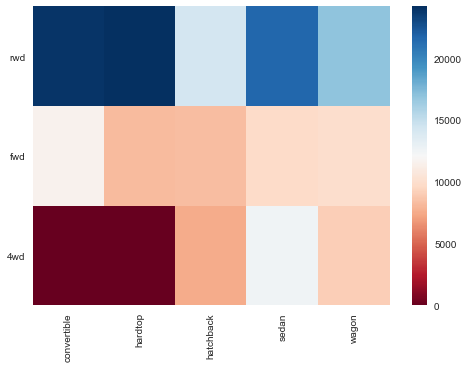

In [39]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

#label names
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

#move ticks and labels to the center
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

#rotate label if too long
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

시각화는 데이터과학에서 매우 중요하며 Python 시각화 패키지는 아주 유용합니다. 세종사이버대학교 컴퓨터·AI공학과의 2학기 수업으로 제공되는 '데이터시각화 과정에서 시각화 원칙 및 Python 데이터 시각화를 더 심도있게 다룰 것입니다.

여기서 우리가 다루고자 주요 질문은 **"자동차 가격에 가장 큰 영향을 미치는 주요 특징은 무엇입니까?**"입니다.

이를 위하여, 다음과 같이 <code>pandas.plotting.scatter_matrix()</code> ([Pandas Visualization User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html?highlight=groupby%20sum)참조), [How to use Pandas Scatter Matrix(Pair Plot) to Visualize Data](https://www.marsja.se/pandas-scatter-matrix-pair-plot/)를 참조하여 dataframe내 수치형 열(columns)간의 관계를 전체적으로 시각화하여 확인하여 Price와 상관관계가 있는 변수들을 확인할 있다. 

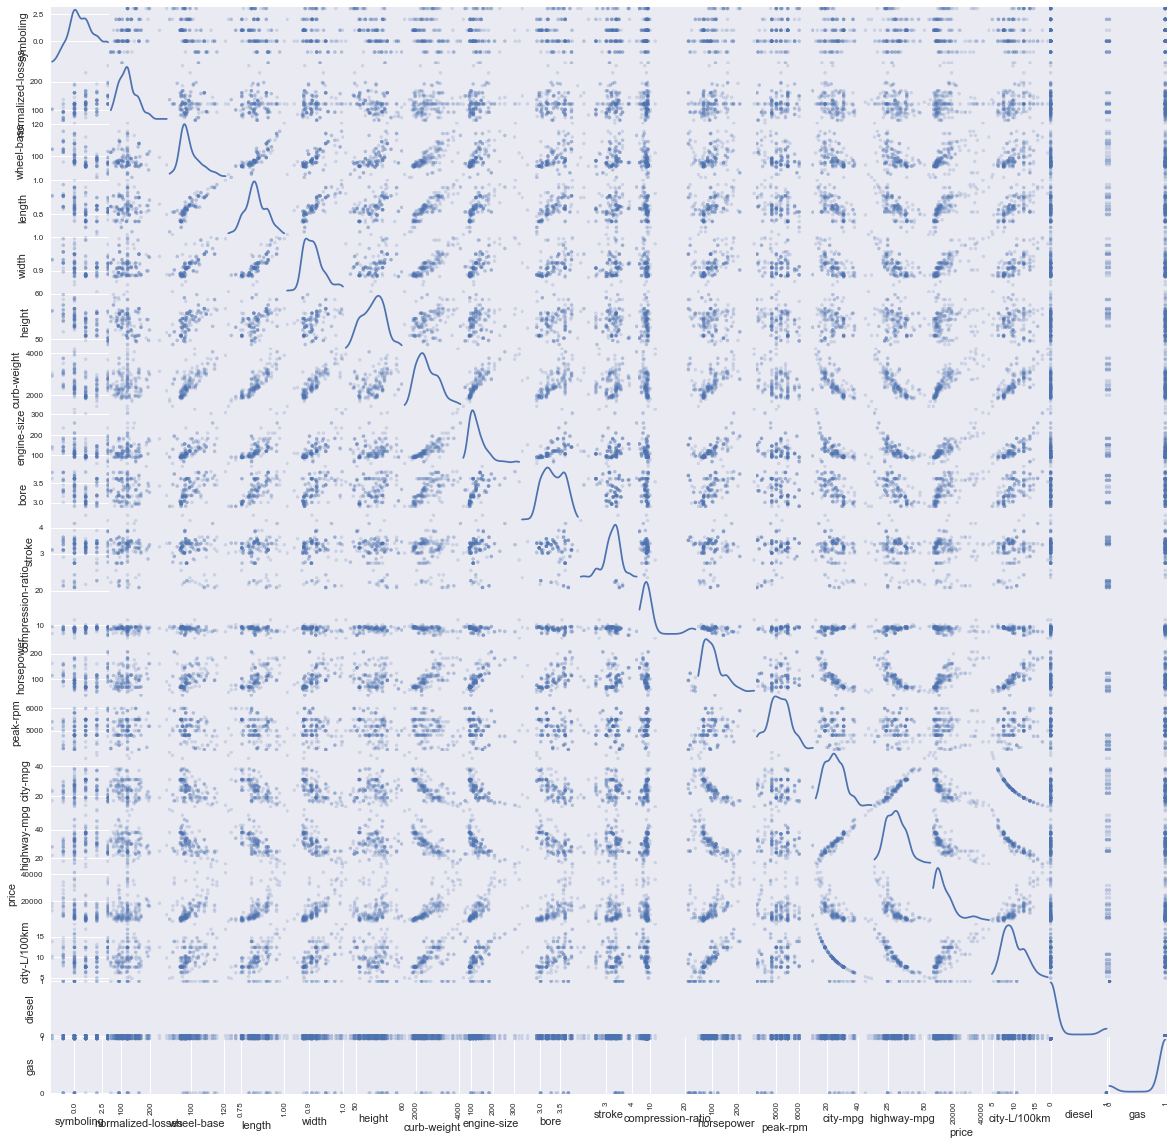

In [44]:
pd.plotting.scatter_matrix(df, alpha=0.2, figsize=(20, 20), diagonal='kde')
plt.show()

<code>seaborn.pairplot()</code>도 이와 같은 경향을 좀더 적은 코드로 쉽게 이용할 수 있도록 해줍니다(주의 사항 : **아래 pairplot함수는 실행에 수분 정도가 소요될 수 있습니다**). 

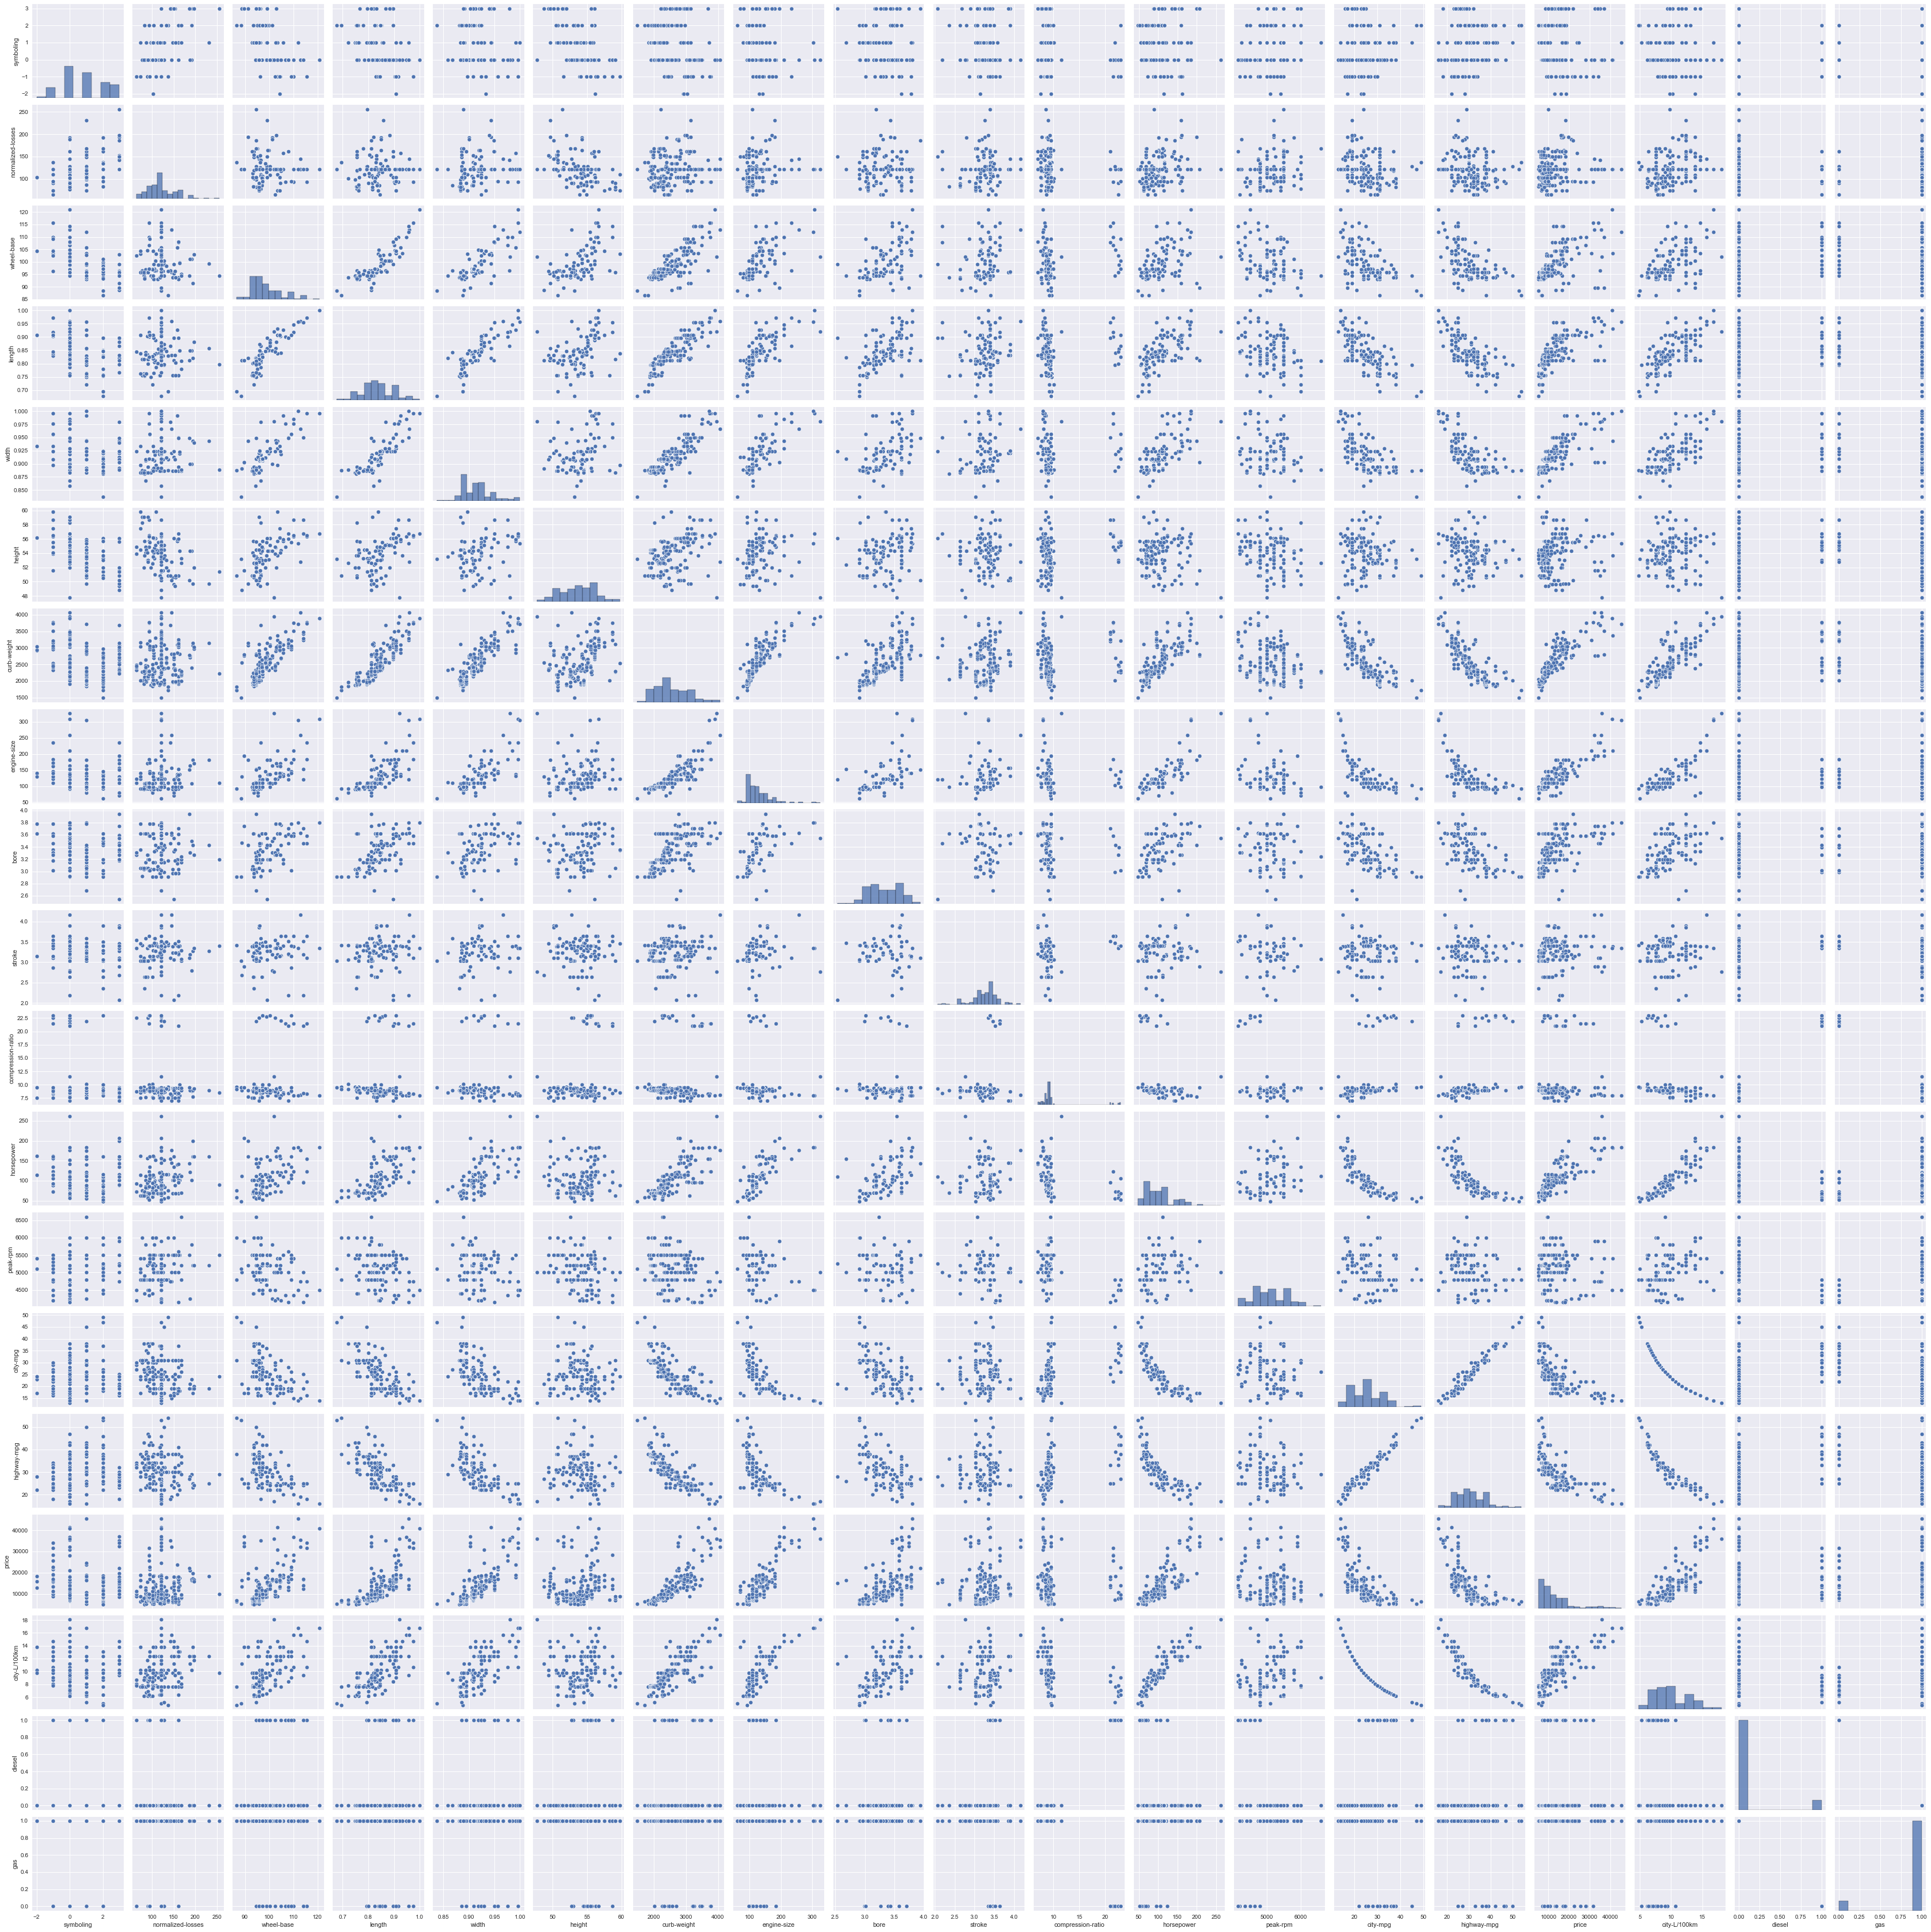

In [45]:
_ = sns.pairplot(df) # you can suppress plt outputs by adding ";"" or plt.show() or assign temporary variable 

이제 부터 중요한 특성을 더 잘 측정하기 위해 이러한 변수들과 자동차 가격의 상관관계를 살펴볼 것입니다. 즉, 자동차 가격이 이러한 변수들에 어떻게 의존 하는가?

<h2 id="correlation_causation">5. 상관관계 및 인과관계</h2>

<p> <b>상관관계(correlation) </b> : 변수 간의 상호 의존 정도를 측정</p>

<p> <b>인과관계(causation)</b> : 두 변수 간의 원인과 결과 간의 관계</p>

<p>상관관계와 인과관계의 차이를 아는 것이 중요합니다. 상관 관계가 있다는것이 인과 관계를 의미하지는 않습니다. 상관 관계를 결정하는 것은 인과 관계를 결정하는 것보다 훨씬 간단합니다. 인과 관계는 독립적인 실험이 필요할 수 있습니다.

<p> Pearson 상관관계 </p>
<p> Pearson Correlation은 두 변수 X와 Y 간의 선형 의존성을 측정합니다. </p>
<p> 결과 계수는 -1과 1 사이의 값입니다. </p>
<ul>
    <li> <b> 1 </b>: 완전한 양의 선형 상관 관계 </li>
    <li> <b> 0 </b>: 선형 상관 관계가 없으며 두 변수가 서로 영향을 미치지 않을 가능성이 높습니다. </li>
    <li> <b> -1 </b>: 완전한 음의 선형 상관 관계 </li>
</ul>

<p> Pearson Correlation은 'corr'함수에서 디폴트입니다. 이전과 마찬가지로 'int64' 또는 'float64'변수들에 대해 Pearson 상관 관계를 계산하도록 하겠습니다. </p>

In [40]:
df.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


<AxesSubplot:>

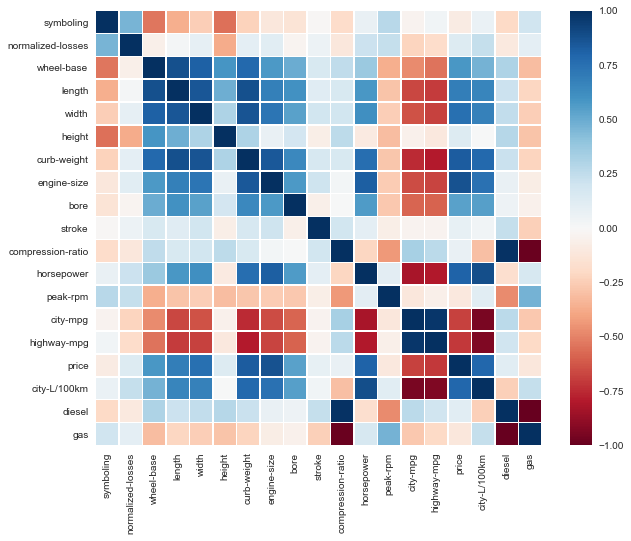

In [41]:
# 수치형 열(column)간의 상관관계를 시각화하면 다음과 같다

plt.figure(figsize=(10,8))
sns.heatmap(data = df.corr(),linewidths=.5, cmap='RdBu')

이제 상관 추정치의 통계적 유의성에 대해 확인해봅시다. 

<p>P-value는 무엇일까요? P-value는 두 변수 간의 상관 관계가 통계적으로 유의할 확률 값입니다. 일반적으로 0.05의 유의 수준을 선택합니다. 즉, 변수 간의 상관 관계가 유의하다고 95 % 확신합니다. </p>

<ul>
    <li> p-value $<$ 0.001 : 상관 관계가 중요하다는 강력한 증거가 있다고 말합니다. </li>
    <li> p-value $<$ 0.05 :  상관 관계가 유의하다는 보통의 증거가 있습니다. </li>
    <li> p-value $<$ 0.1 : 상관 관계가 유의하다는 약한 증거가 있습니다. </li>
    <li> p-value $>$ 0.1 : 상관 관계가 유의하다는 증거가 없습니다. </li>
</ ul>

"scipy"라이브러리의 "stats"모듈을 사용하여 이 정보를 얻을 수 있습니다.

In [42]:
from scipy import stats

<h3>5.1 Wheel-base vs Price</h3>

Pearson 상관계수와 'wheel-base'와 'price'의 P-value를 계산해 봅시다.

In [43]:
pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print("피어슨 상관계수(Pearson Correlation Coefficient): ", pearson_coef, ",  P-value 값: ", p_value)  

피어슨 상관계수(Pearson Correlation Coefficient):  0.5846418222655081 ,  P-value 값:  8.076488270732989e-20


<h4> 결론 : </h4>
<p> 선형 관계가 매우 강하지는 않지만(~ 0.585), p-value가 $<$ 0.001이므로 wheel-base와 price간 상관 관계는 통계적으로 유의미합니다. </p>

<h3>5.2 Horsepower vs Price</h3>

Pearson 상관계수와 'horsepower'와 'price'의 P-value를 계산해 봅시다.

In [44]:
pearson_coef, p_value = stats.pearsonr(df['horsepower'], df['price'])
print("피어슨 상관계수:", pearson_coef, ", P value :", p_value)  

피어슨 상관계수: 0.809574567003656 , P value : 6.369057428259557e-48


<h4> 결론 : </h4>

<p> p값이 $<$ 0.001이므로 horsepower와  price간 상관 관계가 통계적으로 유의하며, 선형 관계가 상당히 강합니다(~ 0.809, 1에 가까움) </p>

<h3>5.3 Length vs Price</h3>

Pearson 상관계수와 'length'와 'price'의 P-value를 계산해 봅시다.

In [45]:
pearson_coef, p_value = stats.pearsonr(df['length'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.690628380448364  with a P-value of P =  8.016477466158986e-30


<h4> 결론 : </h4>

<p> p값이 $<$ 0.001이므로 length와 price 간의 상관 관계가 통계적으로 유의하고, 선형 관계가 약간 강합니다 (~ 0.691). </p>

<h3>5.4 Width vs Price</h3>

Pearson 상관계수와 'width'와 'price'의 P-value를 계산해 봅시다.

In [46]:
pearson_coef, p_value = stats.pearsonr(df['width'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value ) 

The Pearson Correlation Coefficient is 0.7512653440522674  with a P-value of P = 9.200335510481516e-38


<h4> 결론 : </h4>

p값이 0.001 미만이므로 width와 price간의 상관 관계가 통계적으로 유의하고, 선형 관계가 매우 강합니다 (~ 0.751).

### 5.5 Curb-weight vs Price

Pearson 상관계수와 'curb-weight'와 'price'의 P-value를 계산해 봅시다.

In [47]:
pearson_coef, p_value = stats.pearsonr(df['curb-weight'], df['price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.8344145257702846  with a P-value of P =  2.1895772388936914e-53


<h4> 결론 : </h4>

<p> p값이 $<$ 0.001이므로 curb-weight와 price 간의 상관 관계가 통계적으로 유의하고, 선형 관계가 상당히 강합니다 (~ 0.834). </p>

<h3>5.6 Engine-size vs Price</h3>

Pearson 상관계수와 'engine-size'와 'price'의 P-value를 계산해 봅시다.

In [48]:
pearson_coef, p_value = stats.pearsonr(df['engine-size'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value) 

The Pearson Correlation Coefficient is 0.8723351674455185  with a P-value of P = 9.265491622198389e-64


<h4> 결론 : </h4>

<p> p값이 $<$ 0.001이므로 engine-size와 price 간 상관 관계가 통계적으로 유의하고, 선형 관계가 매우 강합니다 (~ 0.872). </p>

<h3>5.7 Bore vs Price</h3>

Pearson 상관계수와 'bore'와 'price'의 P-value를 계산해 봅시다.

In [49]:
pearson_coef, p_value = stats.pearsonr(df['bore'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =  ", p_value ) 

The Pearson Correlation Coefficient is 0.5431553832626602  with a P-value of P =   8.049189483935489e-17


<h4> 결론 : </h4>

<p> p값이 $<$ 0.001이므로 bore와 price 간 상관 관계는 통계적으로 유의하지만, 선형 관계는 보통 (~ 0.521)입니다. </p>

<h3>5.8 City-mpg vs Price</h3>

Pearson 상관계수와 'City-mpg'와 'price'의 P-value를 계산해 봅시다.

In [50]:
pearson_coef, p_value = stats.pearsonr(df['city-mpg'], df['price'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is -0.6865710067844677  with a P-value of P =  2.321132065567674e-29


<h4> 결론 : </h4>

<p> p값이 $<$ 0.001이므로 city-mpg와 price간 상관 관계가 통계적으로 유의미하고, ~ -0.687의 계수값은 음의 상관관계로 약간 강한 것을 보여줍니다. </p>

<h3>5.9 Highway-mpg vs Price</h3>

Pearson 상관계수와 'Highway-mpg'와 'price'의 P-value를 계산해 봅시다.

In [51]:
pearson_coef, p_value = stats.pearsonr(df['highway-mpg'], df['price'])
print( "The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value ) 

The Pearson Correlation Coefficient is -0.7046922650589529  with a P-value of P =  1.7495471144477352e-31


<h4> 결론 : </h4>

p값이 0.001 미만이므로 highway-mpg와 price간의 상관 관계가 통계적으로 유의하고 ~ -0.705 계수값은 음의 상관관계로 중간 정도 강함을 보여줍니다.

### 5.10 Interactive widgets을 이용한 Pearson Correlation Coefficient와 P-value 

위와 같이 두개의 수치형 변수에 대해 각각 상관계수(Correlaton coefficient)와 P-value를 구하는 코드 작성을 interactive widget으로 구현해 보고자 한다. 

In [52]:
from scipy import stats

#### Interactive IPython Widgets 실행 환경 준비  
Interactive IPython Widgets을 실행하기 위해서는, 2주차 수업에서 설명한 바와 같이 Jupyterlab v3 환경기반으로 ipympl모듈이 설치되어 있어야 합니다. 

다음은 [Using interact](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html)를 참고하였습니다.

In [53]:
# The interact function (ipywidgets.interact) automatically creates user interface (UI) controls for exploring code and data interactively. It is the easiest way to get started using IPython’s widgets.
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

다음은  WillKoehrsen의 [Introduction:IPython Widgets](https://github.com/WillKoehrsen/Data-Analysis/blob/master/widgets/Widgets-Overview.ipynb)을 참고하였습니다. 

In [54]:
# Show all code cells outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

함수를 대화형(interactive)으로 만들려면 interact decorator를 사용하기만 하면 됩니다. 그러면 드롭박스에서 사용자가 선택한 입력 타입에 대해 자동으로 상관계수와 P값을 추론하여 제공합니다.!

In [56]:
@interact
def correlations(column1=list(df.select_dtypes('number').columns), 
                 column2=list(df.select_dtypes('number').columns)):
    pearson_coef, p_value = stats.pearsonr(df[column1], df[column2])
    print( "\nPearson 상관계수(Correlation Coefficient): ", pearson_coef, ", P값 :", p_value ) 
#   print(f"Correlation: {df[column1].corr(df[column2])}")     

interactive(children=(Dropdown(description='column1', options=('symboling', 'normalized-losses', 'wheel-base',…

<h2 id="anova">6. 분산분석(ANOVA)</h2>

<h3>6.1 분산분석(ANOVA, Analysis of Variance)</h3>

<p> 분산분석(ANOVA)은 두개 이상의 그룹의 평균 간에 유의한 차이가 있는지 여부를 테스트하는 데 사용되는 통계 방법입니다. ANOVA는 두 개의 파라미터를 반환합니다. </p>

<p> <b> F-test score</b> : ANOVA는 모든 그룹의 평균이 동일하다고 가정하고 실제 평균이 동일하다고 한 가정에서 얼마나 벗어나는지 계산하여 이를 F-test score로 보고합니다. F-test score가 클수록 평균 간의 차이가 더 크다는 것을 의미합니다. </p>

<p> <b> P-value</b> : P 값은 계산된 F-test score가 통계적으로 얼마나 유의한지 알려줍니다. </p>

<p> price변수가 분석 중인 변수와 강력한 상관 관계가있는 경우 ANOVA가 상당한 F-test score 값과 작은 p값을 반환하게 될 것입니다. </p>

<h3> 6.2 자동차 메이커(Make) </h3>   

#### 6.2.1 서로 다른 'make' 즉 honda, subaru, jajuar가 'price'에 영향을 미치는지 살펴 보겠습니다.

먼저 make열에 honda, subaru, jaguar를 가지는 것을 확인해봅니다. 

In [57]:
h_df = df["make"] == "honda"
s_df = df["make"] == "subaru"
j_df = df["make"] == "jaguar"

hsj_df = df[h_df | s_df | j_df] 
## hsj_df = pd.concat([pd.DataFrame(h_df), pd.DataFrame(s_df), pd.DataFrame(j_df)])
hsj_df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
29,2,137,honda,std,two,hatchback,fwd,front,86.6,0.694858,...,9.6,58.0,4800.0,49,54,6479.0,4.795918,Low,0,1
30,2,137,honda,std,two,hatchback,fwd,front,86.6,0.694858,...,9.2,76.0,6000.0,31,38,6855.0,7.580645,Low,0,1
31,1,101,honda,std,two,hatchback,fwd,front,93.7,0.720807,...,10.1,60.0,5500.0,38,42,5399.0,6.184211,Low,0,1
32,1,101,honda,std,two,hatchback,fwd,front,93.7,0.720807,...,9.2,76.0,6000.0,30,34,6529.0,7.833333,Low,0,1
33,1,101,honda,std,two,hatchback,fwd,front,93.7,0.720807,...,9.2,76.0,6000.0,30,34,7129.0,7.833333,Low,0,1


메이커별 평균 가격을 바차트로 확인해보시다.

<AxesSubplot:xlabel='make'>

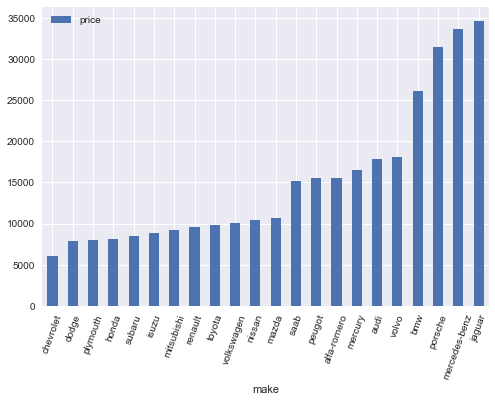

In [58]:
df_group_make = df[['make', 'price']]

## dataframe을 이용해서 그리기
df_group_make = df_group_make.groupby(['make']).mean().sort_values(['price'],ascending=True)
df_group_make.plot(kind='bar', rot=70)
plt.show()

## seaborn을 이용해서 그리기
# df_group_make = df_group_make.groupby(['make'],as_index=False).mean()
# ax = sns.barplot(x='make', y='price', data = df_group_make, order=df_group_make.sort_values('price').make)
# ax.set_xticklabels(ax.get_xticklabels(),rotation=70)
# plt.show()

## matplotlib을 이용해서 그리기
# df_group_make = df_group_make.groupby(['make'],as_index=False).mean().sort_values(['price'],ascending=True)
# plt.bar(df_group_make['make'], df_group_make['price'])
# plt.xticks(rotation=80)
# plt.show()

In [59]:
df_group_make

,price
make,
chevrolet,6007.000000
dodge,7875.444444
plymouth,7963.428571
honda,8184.692308
subaru,8541.250000
isuzu,8916.500000
mitsubishi,9239.769231
renault,9595.000000
toyota,9885.812500


make열의 honda, subaru, jaguar그룹이 price에 영향을 미치는 지 확인해보고자 합니다. 먼저 <code>seaborn.swarmplot()</code>을 통하여 각 케이스별 점의 위치를 통해 확인해봅니다. 

<AxesSubplot:xlabel='make', ylabel='price'>

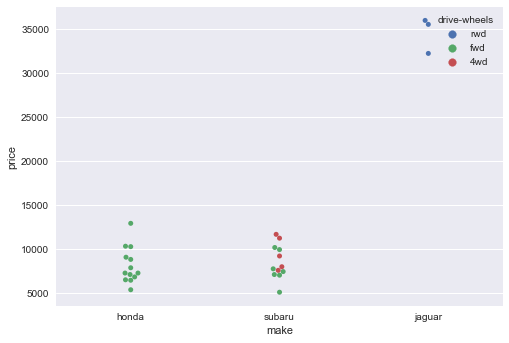

In [60]:
sns.swarmplot(data=df,x='make', y='price', hue='drive-wheels', order =["honda","subaru","jaguar"])

이번에는 FacetGrid를 활용하여 drive-wheels별로 구분하여 swarm plot을 나타내봅니다. 고가로 팔리는 jaguar의 경우 rwd즉 후륜구동이 많다는 것을 확인할 수 있습니다. 

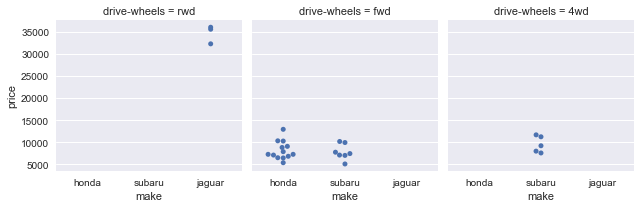

In [61]:
# make - "honda", "subaru" and "jaguar"

g = sns.FacetGrid(data=df, col = 'drive-wheels')
g.map(sns.swarmplot,'make', 'price', order =["honda","subaru","jaguar"])

make열의 honda, subaru, jaguar그룹이 price에 영향을 미치는 지 확인해보고기 위하여, 이번에는 <code>seaborn.swarmplot()</code>과 함께 평균 및 분포를 확인하기 위하여 <code>seaborn.boxplot()</code>을 함께 확인합니다. honda와 subaru 그룹은 그룹간 평균의 차이가 작고 각 그룹내 분산이 커보이므로 그룹이 가격에 미치는 영향이 작아보입니다. 이에 반해 honda와 jaguar 그룹의 경우 그룹간 평균의 차이가 크고, 각  그룹내 분산이 이러한 평균의 차이에 비해 작아 보입니다. 이것은 honda와 jaguar 그룹은 가격에 미치는 영향이 클 것으로 보입니다. 

<AxesSubplot:xlabel='make', ylabel='price'>

<AxesSubplot:xlabel='make', ylabel='price'>

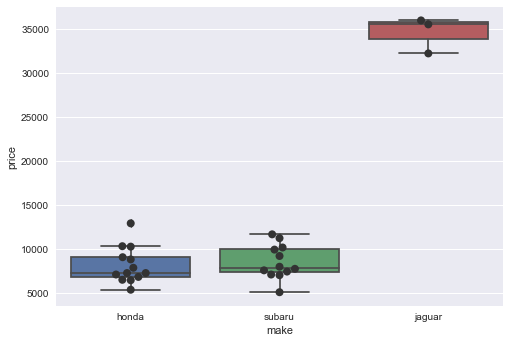

In [62]:
# sns.set(style="whitegrid")

# sns.swarmplot(x="make", y="price",  hue="drive-wheels", data=hsj_df, size=10)
sns.swarmplot(x="make", y="price", data=df, size=8, color=".2", order =["honda","subaru","jaguar"] )
sns.boxplot(x="make", y="price", data=df, order =["honda","subaru","jaguar"])

---

[Robust and Beautiful Statistical Visualization](https://acclab.github.io/DABEST-python-docs/robust-beautiful.html)을 참조하여 Estimation statistics를 위한 plot중 하나인 cumming plot를 작성할 수도 있습니다. dabest 실행은 선택사항입니다.
- [Estimation statistics](https://en.wikipedia.org/wiki/Estimation_statistics) is a data analysis framework that uses a combination of effect sizes, confidence intervals, precision planning, and meta-analysis to plan experiments, analyze data and interpret results. It is distinct from null hypothesis significance testing (NHST), which is considered to be less informative. Estimation statistics, or simply estimation, is also known as the new statistics. 
- For multiple groups, Geoff Cumming introduced the use of a secondary panel to plot two or more mean differences and their confidence intervals, placed below the observed values panel;This arrangement enables easy comparison of mean differences ('deltas') over several data groupings.  

이러한 cumming plot을 작성하기 위해서는 [dabest](https://github.com/ACCLAB/DABEST-python)가 설치되어 있어야 합니다. dabest설치를 위해서는 `!pip install dabest`(upgrade시는 `!pip install --upgrade dabest`) 부분  커멘트 block을 해제한 후 실행하시기 바랍니다. 해당 부문 실행으로 처음 dbbest 설치한 후에는 해당 부문을 다시 comment처리하시고 kernel을 restart하후 이 notebook의 처음부터 다시 cell을 실행하시기 바랍니다  

In [71]:
# !pip install dabest 

In [72]:
import dabest

print("We're using DABEST v{}".format(dabest.__version__)) # dabest의 version을 확인합니다. 

We're using DABEST v0.3.1


In [73]:
# load data into 'dabest'
hsj_dabest = dabest.load(data = df, x="make", y="price", idx=("honda","subaru","jaguar"))
hsj_dabest

DABEST v0.3.1
             
Good evening!
The current time is Mon May  3 12:06:46 2021.

Effect size(s) with 95% confidence intervals will be computed for:
1. subaru minus honda
2. jaguar minus honda

5000 resamples will be used to generate the effect size bootstraps.

C:\Users\user\anaconda3\envs\ds\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


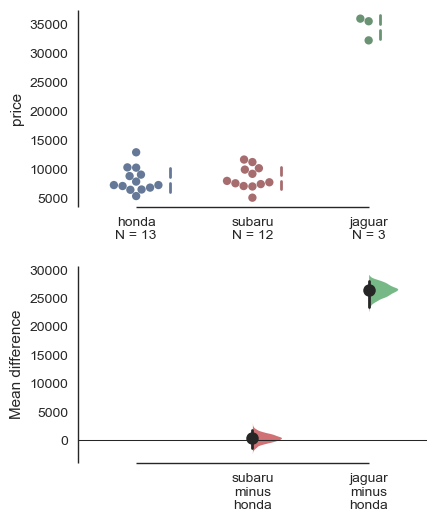

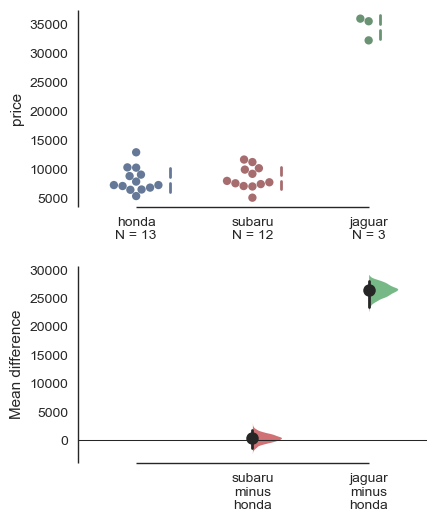

In [74]:
# produce a Cumming estimation plot

hsj_dabest.mean_diff.plot() # effect sizes of mean difference
# plt.tight_layout()

---------

이제 ANOVA를 통해 위에서 시각화를 통해서 인지한 것을 확인해봅니다. 

<p> ANOVA는 동일 변수내 서로 다른 그룹 간의 차이를 분석하므로 groupby 함수가 유용합니다. ANOVA 알고리즘은 데이터의 평균을 자동으로 계산하기 때문에 사전에 평균을 계산할 필요가 없습니다. </p>

**서로 다른 'make'가 'price'에 영향을 미치는지 살펴 보겠습니다**. 
데이터를 그룹화합니다.
모듈 'stats'에서 'f_oneway'함수를 사용하여 <b>F-test score</b> 및 <b> P-value </b>를 얻을 수 있습니다.

In [75]:
# ANOVA between "honda", "subaru" and "jaguar"
df_anova = df[["make", "price"]]
grouped_anova = df_anova.groupby(["make"])

f_val, p_val = stats.f_oneway(grouped_anova.get_group('honda')['price'], grouped_anova.get_group('subaru')['price'],grouped_anova.get_group('jaguar')['price'])  
print("ANOVA results: F=", f_val, ", P =", p_val)   

ANOVA results: F= 228.8813913405773 , P = 8.464042477638846e-17


결과가 아주 좋습니다. 큰 F-test score는 강한 상관 관계를 보여주며, 거의 0에 가까운 P값은 통계적 유의성을 의미하네요. 그러나 이러한 결과가 테스트 대상인 세 그룹이 모두 높은 상관 관계를 가진다는 것일 까요? 이제 부터 한번 확인해봅시다. 

In [76]:
# grouped_anova.get_group("honda")
# grouped_anova.get_group("subaru")
# grouped_anova.get_group("jaguar")

#### 6.2.2 honda와 subaru에 대해 알아봅시다.

In [77]:
# ANOVA between "honda" and "subaru"
df_anova = df[["make", "price"]]
grouped_anova = df_anova.groupby(["make"])

f_val, p_val = stats.f_oneway(grouped_anova.get_group('honda')['price'], grouped_anova.get_group('subaru')['price'])  
print("ANOVA results: F=", f_val, ", P =", p_val) 

ANOVA results: F= 0.19744030127462606 , P = 0.6609478240622193


#### 6.2.3 handa와 jaguar에 대해 알아봅시다

In [78]:
# ANOVA between "honda" and "jaguar"
df_anova = df[["make", "price"]]
grouped_anova = df_anova.groupby(["make"])

f_val, p_val = stats.f_oneway(grouped_anova.get_group('honda')['price'], grouped_anova.get_group('jaguar')['price'])  
print("ANOVA results: F=", f_val, ", P =", p_val)   

ANOVA results: F= 400.925870564337 , P = 1.0586193512077862e-11


<h3>6.3 Drive Wheels</h3>

<p> ANOVA는 같은 변수내 서로 다른 그룹 간의 차이를 분석하므로 groupby 함수가 유용합니다. ANOVA 알고리즘은 데이터의 평균을 자동으로 계산하기 때문에 사전에 평균을 계산할 필요가 없습니다. </ p>

#### 6.3.1 **'drive-wheels' 타입 즉 fwd, 4wd, rwd가  'price'에 영향을 미치는지 살펴 보겠습니다**
다음과 같이 데이터를 그룹화합니다.

In [79]:
grouped_test2=df_gptest[['drive-wheels', 'price']].groupby(['drive-wheels'])
grouped_test2.head(2)

,drive-wheels,price
0,rwd,13495.0
1,rwd,16500.0
3,fwd,13950.0
4,4wd,17450.0
5,fwd,15250.0
136,4wd,7603.0


In [80]:
#df_gptest

In [81]:
#grouped_test2의 get_group()으로 특정 그룹에 대해 조회해 본다. 
grouped_test2.get_group('4wd')['price']

4      17450.0
136     7603.0
140     9233.0
141    11259.0
144     8013.0
145    11694.0
150     7898.0
151     8778.0
Name: price, dtype: float64

모듈 'stats'에서 'f_oneway'함수를 사용하여 <b> F-test score</b> 및 <b> P-value </b>를 얻을 수 있습니다.

In [70]:
# ANOVA
f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('rwd')['price'], grouped_test2.get_group('4wd')['price'])  
 
print( "ANOVA results: F=", f_val, ", P =", p_val)   

ANOVA results: F= 67.95406500780399 , P = 3.3945443577151245e-23


이것은 큰 F-test score가 강한 상관 관계를 보여주고 거의 0에 가까운 P 값은 통계적 유의성을 의미하는 훌륭한 결과입니다. 그러나 이것이 테스트 대상인 3 그룹이 모두 이처럼 높은 상관 관계를 가지고 있음을 의미할까요? 한번 확인해보겠습니다. 

#### 6.3.2 fwd와 rwd에 대하여 알아봅시다

In [71]:
f_val, p_val = stats.f_oneway(grouped_test2.get_group('fwd')['price'], grouped_test2.get_group('rwd')['price'])  
 
print( "ANOVA results: F=", f_val, ", P =", p_val )

ANOVA results: F= 130.5533160959111 , P = 2.2355306355677845e-23


Let's examine the other groups 

#### 6.3.3 4wd와rwd에 대하여알아봅시다

In [72]:
f_val, p_val = stats.f_oneway(grouped_test2.get_group('4wd')['price'], grouped_test2.get_group('rwd')['price'])  
   
print( "ANOVA results: F=", f_val, ", P =", p_val)   

ANOVA results: F= 8.580681368924756 , P = 0.004411492211225333


<h4>6.3.4 4wd와 fwd에 대하여 알아봅시다</h4>

In [73]:
f_val, p_val = stats.f_oneway(grouped_test2.get_group('4wd')['price'], grouped_test2.get_group('fwd')['price'])  
 
print("ANOVA results: F=", f_val, ", P =", p_val)   

ANOVA results: F= 0.665465750252303 , P = 0.41620116697845666


<h3>6.4 결론 : 중요 변수들</h3>

<p> 이제 데이터가 어떻게 생겼는지, 자동차 가격을 예측할 때 고려해야 할 변수가 무엇인지 더 잘 파악했습니다. 이제 다음과 같은 변수들이 중요하다는 것이 확인되었습니다.</p>

연속형 수치 변수(Continuous numerical variables):
<ul>
    <li>Length</li>
    <li>Width</li>
    <li>Curb-weight</li>
    <li>Engine-size</li>
    <li>Horsepower</li>
    <li>City-mpg</li>
    <li>Highway-mpg</li>
    <li>Wheel-base</li>
    <li>Bore</li>
</ul>
    
범주형 변수(Categorical variables):
<ul>
    <li>Drive-wheels</li>
</ul>

<p> 이후 다음 수업 부터 머신러닝 모델을 구축하게 됩니다. 이 때 모델의 예측 성능 향상을 위해, 목표 변수에 의미있는 영향을 미치는 위의 변수들을 활용하게 됩니다.</p>

<h1>저자 정보:</h1>

이 노트북의 작성자는 <a href="https://www.linkedin.com/in/mahdi-noorian-58219234/" target="_blank">Mahdi Noorian PhD</a>, <a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>, Bahare Talayian, Eric Xiao, Steven Dong, Parizad, Hima Vsudevan 및 <a href="https://www.linkedin.com/in/fiorellawever/" target="_blank">Fiorella Wenver</a> 및 <a href=" https://www.linkedin.com/in/yi-leng-yao-84451275/ " target="_blank" >Yi Yao</a>입니다.

<p> <a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>는 IBM의 데이터 과학자이며 전기공학으로 박사 학위를 받았습니다. 그의 연구는 머신 러닝, 신호 처리 및 컴퓨터 비전을 사용하여 동영상이 인간의 인지에 미치는 영향을 확인하는 데 중점을 두었습니다. Joseph은 박사 학위를 취득한 이후 IBM에서 근무하고 있습니다. </p>

<hr>
<p>Copyright &copy; 2018 IBM Developer Skills Network. This notebook and its source code are released under the terms of the <a href="https://cognitiveclass.ai/mit-license/">MIT License</a>.</p>